# Phase 3: LSTM plant-model training

Train and validate a compact one-step DC motor model, then test whether recursive forecasts remain credible for a future MPC horizon.

In [1]:
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / 'src'))

from lstm_model import LSTMForecaster, recursive_forecast

## Configuration and reproducibility

In [2]:
SEED = 2026
MODEL_CONFIG = {
    'input_size': 2,
    'hidden_size': 64,
    'num_layers': 2,
    'dropout': 0.2,
    'output_size': 1,
    'residual': True,
}
TRAINING_CONFIG = {
    'batch_size': 512,
    'learning_rate': 1e-3,
    'max_epochs': 60,
    'patience': 8,
    'min_delta': 1e-6,
}

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
torch.set_num_threads(min(4, torch.get_num_threads()))
device = torch.device('cpu')
print(f'PyTorch {torch.__version__}, device={device}')

PyTorch 2.13.0+cpu, device=cpu


## Load the Phase 2 dataset

In [3]:
dataset_path = project_root / 'data' / 'processed' / 'dc_motor_lstm_dataset.npz'
data = np.load(dataset_path)

X_train = data['X_train']
y_train = data['y_train']
X_validation = data['X_validation']
y_validation = data['y_validation']
X_test = data['X_test']
y_test = data['y_test']
window_length = int(data['window_length'])
input_mean = data['normalization_input_mean']
input_std = data['normalization_input_std']
target_mean = data['normalization_target_mean']
target_std = data['normalization_target_std']

assert data['feature_names'].tolist() == ['voltage', 'y_measured']
assert str(data['target_name']) == 'y_true'
print(f'train={X_train.shape}, validation={X_validation.shape}, test={X_test.shape}')

train=(21258, 20, 2), validation=(7086, 20, 2), test=(7086, 20, 2)


In [4]:
def make_loader(inputs, targets, shuffle=False):
    dataset = TensorDataset(torch.from_numpy(inputs), torch.from_numpy(targets))
    generator = torch.Generator().manual_seed(SEED) if shuffle else None
    return DataLoader(
        dataset,
        batch_size=TRAINING_CONFIG['batch_size'],
        shuffle=shuffle,
        generator=generator,
    )


train_loader = make_loader(X_train, y_train, shuffle=True)
validation_loader = make_loader(X_validation, y_validation)
test_loader = make_loader(X_test, y_test)
model = LSTMForecaster(**MODEL_CONFIG).to(device)
print(f'{sum(parameter.numel() for parameter in model.parameters()):,} trainable parameters')

50,753 trainable parameters


## Train with validation-based early stopping

In [5]:
@torch.no_grad()
def evaluate_mse(model, loader):
    model.eval()
    squared_error = 0.0
    count = 0
    for inputs, targets in loader:
        predictions = model(inputs.to(device))
        squared_error += torch.sum((predictions - targets.to(device)) ** 2).item()
        count += targets.numel()
    return squared_error / count


criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=TRAINING_CONFIG['learning_rate'])
history = {'train_loss': [], 'validation_loss': []}
best_validation_loss = float('inf')
best_epoch = 0
best_state = None
epochs_without_improvement = 0

for epoch in range(1, TRAINING_CONFIG['max_epochs'] + 1):
    model.train()
    total_loss = 0.0
    count = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        loss = criterion(model(inputs), targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(inputs)
        count += len(inputs)

    train_loss = total_loss / count
    validation_loss = evaluate_mse(model, validation_loader)
    history['train_loss'].append(train_loss)
    history['validation_loss'].append(validation_loss)
    print(f'epoch {epoch:02d}: train={train_loss:.6f}, validation={validation_loss:.6f}')

    if validation_loss < best_validation_loss - TRAINING_CONFIG['min_delta']:
        best_validation_loss = validation_loss
        best_epoch = epoch
        best_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= TRAINING_CONFIG['patience']:
            print(f'Early stopping at epoch {epoch}.')
            break

model.load_state_dict(best_state)
model.eval()
print(f'Best epoch={best_epoch}, validation MSE={best_validation_loss:.6f}')

epoch 01: train=0.001763, validation=0.000418


epoch 02: train=0.000401, validation=0.000362


epoch 03: train=0.000387, validation=0.000357


epoch 04: train=0.000384, validation=0.000357


epoch 05: train=0.000381, validation=0.000351


...

epoch 56: train=0.000301, validation=0.000273


epoch 57: train=0.000282, validation=0.000257


epoch 58: train=0.000244, validation=0.000196


epoch 59: train=0.000192, validation=0.000136


epoch 60: train=0.000154, validation=0.000103
Best epoch=60, validation MSE=0.000103


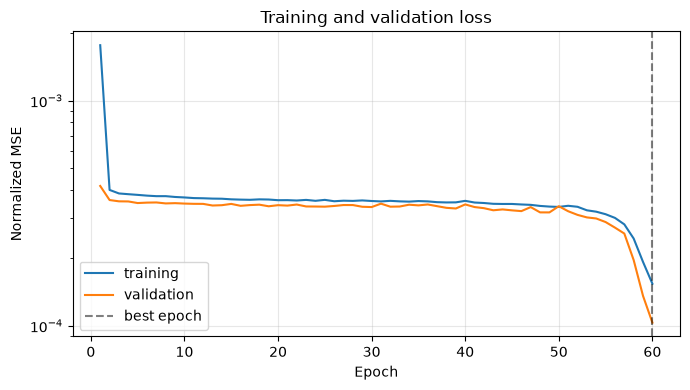

In [6]:
epochs = np.arange(1, len(history['train_loss']) + 1)
plt.figure(figsize=(7, 4))
plt.semilogy(epochs, history['train_loss'], label='training')
plt.semilogy(epochs, history['validation_loss'], label='validation')
plt.axvline(best_epoch, color='black', linestyle='--', alpha=0.5, label='best epoch')
plt.xlabel('Epoch')
plt.ylabel('Normalized MSE')
plt.title('Training and validation loss')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## One-step test performance

In [7]:
@torch.no_grad()
def predict_normalized(model, loader):
    model.eval()
    return np.concatenate([model(inputs.to(device)).cpu().numpy() for inputs, _ in loader])


def regression_metrics(true, predicted):
    error = predicted - true
    rmse = float(np.sqrt(np.mean(error ** 2)))
    return {
        'rmse': rmse,
        'mae': float(np.mean(np.abs(error))),
        'r2': float(1 - np.sum(error ** 2) / np.sum((true - true.mean()) ** 2)),
        'nrmse_range': float(rmse / (true.max() - true.min())),
    }


test_prediction_normalized = predict_normalized(model, test_loader)
test_prediction = test_prediction_normalized[:, 0] * target_std[0] + target_mean[0]
test_true = y_test[:, 0] * target_std[0] + target_mean[0]
persistence_prediction = X_test[:, -1, 1] * input_std[1] + input_mean[1]
test_metrics = regression_metrics(test_true, test_prediction)
persistence_metrics = regression_metrics(test_true, persistence_prediction)

print('LSTM:', {name: round(value, 6) for name, value in test_metrics.items()})
print('Persistence:', {name: round(value, 6) for name, value in persistence_metrics.items()})

LSTM: {'rmse': 0.140873, 'mae': 0.113106, 'r2': 0.999906, 'nrmse_range': 0.002116}
Persistence: {'rmse': 0.289778, 'mae': 0.230993, 'r2': 0.999603, 'nrmse_range': 0.004352}


## Held-out operating-condition comparison

The test trajectories are absent from training. “Held-out nonzero load” means new load sequences on test runs; the torque magnitudes remain within the Phase 2 training range.

In [8]:
test_window_run_ids = data['window_run_ids_test']

def align_raw_test_field(field):
    aligned = np.empty(len(test_window_run_ids), dtype=np.float32)
    for run_id in np.unique(test_window_run_ids):
        positions = np.flatnonzero(test_window_run_ids == run_id)
        aligned[positions] = data[field][run_id, window_length : window_length + len(positions)]
    return aligned


raw_test_true = align_raw_test_field('y_true')
test_load_torque = align_raw_test_field('load_torque')
nominal_values = data['parameter_values'][0]
nominal_run_ids = np.flatnonzero(
    np.all(np.isclose(data['parameter_values'], nominal_values, rtol=0.0, atol=1e-8), axis=1)
)
condition_masks = {
    'nominal_parameters': np.isin(test_window_run_ids, nominal_run_ids),
    'held_out_nonzero_load': test_load_torque > 0.0,
    'mild_parameter_variation': ~np.isin(test_window_run_ids, nominal_run_ids),
}
condition_metrics = {
    name: regression_metrics(test_true[mask], test_prediction[mask])
    for name, mask in condition_masks.items()
}
for name, metrics in condition_metrics.items():
    print(name, {key: round(value, 6) for key, value in metrics.items()})

nominal_parameters {'rmse': 0.140146, 'mae': 0.112264, 'r2': 0.999899, 'nrmse_range': 0.002574}
held_out_nonzero_load {'rmse': 0.141503, 'mae': 0.114196, 'r2': 0.999908, 'nrmse_range': 0.002187}
mild_parameter_variation {'rmse': 0.141234, 'mae': 0.113526, 'r2': 0.999909, 'nrmse_range': 0.002121}


## Unseen-trajectory predictions and residuals

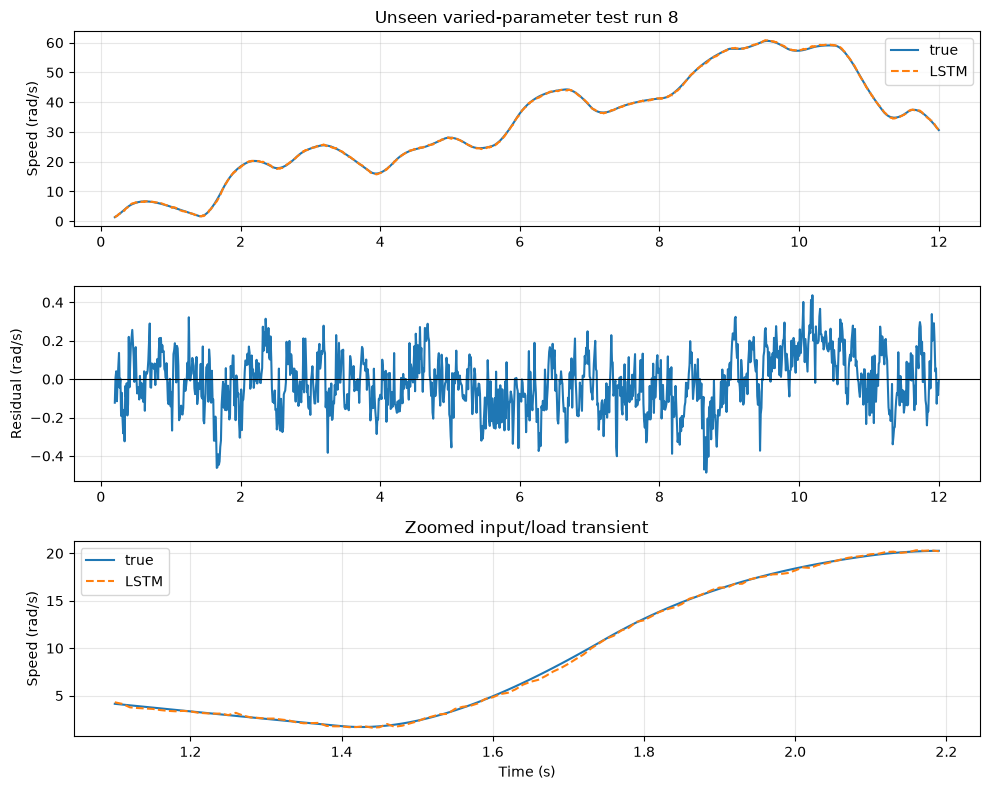

In [9]:
varied_test_runs = [
    int(run_id)
    for run_id in data['split_run_ids_test']
    if run_id not in nominal_run_ids and np.ptp(data['load_torque'][run_id]) > 0
]
chosen_run = varied_test_runs[0]
run_mask = test_window_run_ids == chosen_run
run_time = data['time'][window_length:]
run_true = test_true[run_mask]
run_prediction = test_prediction[run_mask]
run_residual = run_prediction - run_true

changes = np.flatnonzero(
    np.abs(np.diff(data['voltage'][chosen_run]))
    + np.abs(np.diff(data['load_torque'][chosen_run])) > 1e-6
) + 1
eligible_changes = changes[changes > window_length + 50]
zoom_center = int(eligible_changes[0] - window_length) if len(eligible_changes) else len(run_time) // 2
zoom = slice(max(0, zoom_center - 30), min(len(run_time), zoom_center + 80))

fig, axes = plt.subplots(3, 1, figsize=(10, 8))
axes[0].plot(run_time, run_true, label='true')
axes[0].plot(run_time, run_prediction, '--', label='LSTM')
axes[0].set_ylabel('Speed (rad/s)')
axes[0].set_title(f'Unseen varied-parameter test run {chosen_run}')
axes[0].legend()
axes[1].plot(run_time, run_residual)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Residual (rad/s)')
axes[2].plot(run_time[zoom], run_true[zoom], label='true')
axes[2].plot(run_time[zoom], run_prediction[zoom], '--', label='LSTM')
axes[2].set_ylabel('Speed (rad/s)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Zoomed input/load transient')
axes[2].legend()
for axis in axes:
    axis.grid(alpha=0.3)
fig.tight_layout()
plt.show()

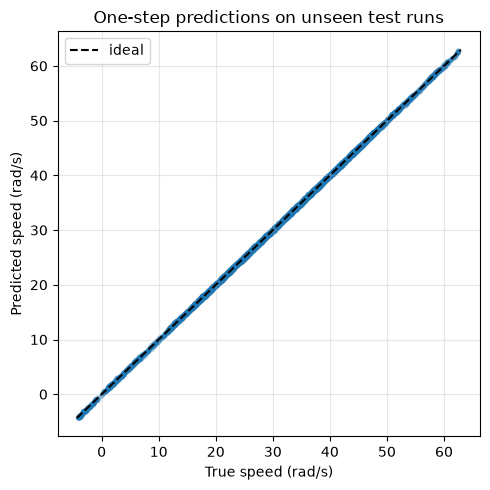

In [10]:
limits = (min(test_true.min(), test_prediction.min()), max(test_true.max(), test_prediction.max()))
plt.figure(figsize=(5, 5))
plt.scatter(test_true, test_prediction, s=8, alpha=0.2)
plt.plot(limits, limits, 'k--', label='ideal')
plt.xlabel('True speed (rad/s)')
plt.ylabel('Predicted speed (rad/s)')
plt.title('One-step predictions on unseen test runs')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Recursive multi-step prediction

Each rollout begins from a real measured history. Future voltage is treated as known, while each predicted physical speed is converted to the input-feature normalization and fed into the next window.

In [11]:
MAX_HORIZON = 15
ROLLOUT_STRIDE = 20
histories = []
future_voltages = []
recursive_true = []

for run_id in data['split_run_ids_test']:
    features = np.column_stack((data['voltage'][run_id], data['y_measured'][run_id]))
    normalized_features = (features - input_mean) / input_std
    normalized_voltage = (data['voltage'][run_id] - input_mean[0]) / input_std[0]
    for target_index in range(
        window_length, len(data['time']) - MAX_HORIZON + 1, ROLLOUT_STRIDE
    ):
        histories.append(normalized_features[target_index - window_length : target_index])
        future_voltages.append(normalized_voltage[target_index : target_index + MAX_HORIZON])
        recursive_true.append(data['y_true'][run_id, target_index : target_index + MAX_HORIZON])

history_tensor = torch.tensor(np.asarray(histories), dtype=torch.float32, device=device)
future_voltage_tensor = torch.tensor(
    np.asarray(future_voltages), dtype=torch.float32, device=device
)
normalization_tensors = [
    torch.tensor(values, dtype=torch.float32, device=device)
    for values in (input_mean, input_std, target_mean, target_std)
]

model.eval()
recursive_prediction_normalized = recursive_forecast(
    model, history_tensor, future_voltage_tensor, *normalization_tensors
).cpu().numpy()
recursive_prediction = recursive_prediction_normalized * target_std[0] + target_mean[0]
recursive_true = np.asarray(recursive_true)
horizon_rmse = np.sqrt(np.mean((recursive_prediction - recursive_true) ** 2, axis=0))

for horizon in (5, 10, 15):
    print(f'H={horizon:2d}: recursive RMSE={horizon_rmse[horizon - 1]:.6f} rad/s')

RMSE_LIMIT = 1.0
recommended_horizon = 0
for horizon, rmse in enumerate(horizon_rmse, start=1):
    if rmse > RMSE_LIMIT:
        break
    recommended_horizon = horizon
recommended_horizon = max(1, recommended_horizon)
print(f'Recommended MPC horizon: H={recommended_horizon} at dt={float(data["timestep"]):.2f} s')

H= 5: recursive RMSE=0.210952 rad/s
H=10: recursive RMSE=0.336461 rad/s
H=15: recursive RMSE=0.487796 rad/s
Recommended MPC horizon: H=15 at dt=0.01 s


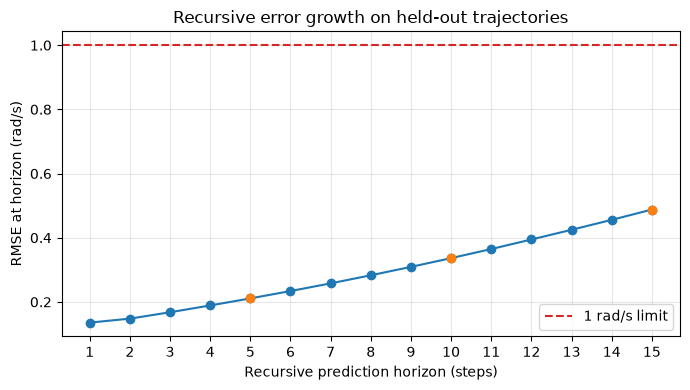

In [12]:
horizons = np.arange(1, MAX_HORIZON + 1)
plt.figure(figsize=(7, 4))
plt.plot(horizons, horizon_rmse, marker='o')
plt.axhline(RMSE_LIMIT, color='tab:red', linestyle='--', label='1 rad/s limit')
plt.scatter((5, 10, 15), horizon_rmse[[4, 9, 14]], color='tab:orange', zorder=3)
plt.xlabel('Recursive prediction horizon (steps)')
plt.ylabel('RMSE at horizon (rad/s)')
plt.title('Recursive error growth on held-out trajectories')
plt.xticks(horizons)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Sanity checks and saved artifacts

In [13]:
assert np.isfinite(test_prediction).all()
assert np.isfinite(recursive_prediction).all()
assert np.allclose(test_true, raw_test_true, atol=1e-4)
assert test_metrics['rmse'] < persistence_metrics['rmse']
assert np.max(np.abs(recursive_prediction)) < 2 * np.max(np.abs(recursive_true)) + 20
assert horizon_rmse[recommended_horizon - 1] <= RMSE_LIMIT

results_dir = project_root / 'results'
metrics_dir = results_dir / 'metrics'
configs_dir = results_dir / 'configs'
metrics_dir.mkdir(parents=True, exist_ok=True)
configs_dir.mkdir(parents=True, exist_ok=True)
weights_path = results_dir / 'lstm_model_weights.pt'
config_path = configs_dir / 'lstm_model_config.json'
history_path = metrics_dir / 'lstm_training_history.npz'
metrics_path = metrics_dir / 'lstm_test_metrics.json'

torch.save(model.state_dict(), weights_path)
np.savez_compressed(
    history_path,
    train_loss=np.asarray(history['train_loss']),
    validation_loss=np.asarray(history['validation_loss']),
    best_epoch=np.array(best_epoch),
)
saved_config = {
    'model': MODEL_CONFIG,
    'training': {**TRAINING_CONFIG, 'seed': SEED, 'best_epoch': best_epoch},
    'dataset': dataset_path.relative_to(project_root).as_posix(),
    'window_length': window_length,
    'features': data['feature_names'].tolist(),
    'target': str(data['target_name']),
    'normalization': {
        'input_mean': input_mean.tolist(),
        'input_std': input_std.tolist(),
        'target_mean': target_mean.tolist(),
        'target_std': target_std.tolist(),
    },
}
config_path.write_text(json.dumps(saved_config, indent=2), encoding='utf-8')
saved_metrics = {
    'best_validation_mse_normalized': best_validation_loss,
    'test': test_metrics,
    'persistence': persistence_metrics,
    'conditions': condition_metrics,
    'recursive_rmse_by_horizon': horizon_rmse.tolist(),
    'recommended_mpc_horizon': recommended_horizon,
}
metrics_path.write_text(json.dumps(saved_metrics, indent=2), encoding='utf-8')

reloaded_model = LSTMForecaster(**MODEL_CONFIG)
reloaded_model.load_state_dict(torch.load(weights_path, map_location='cpu', weights_only=True))
reloaded_model.eval()
with torch.no_grad():
    assert torch.allclose(
        reloaded_model(torch.from_numpy(X_test[:32])),
        model(torch.from_numpy(X_test[:32])),
    )
print('All model sanity checks passed.')
print(f'Saved weights: {weights_path}')
print(f'Saved config under: {configs_dir}; history/metrics under: {metrics_dir}')

All model sanity checks passed.


Saved weights: C:\Users\Lakshya\OneDrive\Desktop\cs\project\results\lstm_model_weights.pt
Saved config under: C:\Users\Lakshya\OneDrive\Desktop\cs\project\results\configs; history/metrics under: C:\Users\Lakshya\OneDrive\Desktop\cs\project\results\metrics


## Phase 3 conclusion

The final plant model is a **two-layer LSTM with 64 hidden units per layer and 0.2 recurrent dropout**, followed by a linear speed-correction output over the latest measured-speed value. With seed 2026, the best normalized validation MSE was **0.000103** at epoch 60. On six completely unseen trajectories, one-step performance was **RMSE 0.1409 rad/s, MAE 0.1131 rad/s, R² 0.999906, and range-normalized RMSE 0.00212**; persistence was substantially worse at **0.2898 rad/s RMSE**.

Recursive RMSE increased from **0.2110 rad/s at H=5** to **0.3365 at H=10** and **0.4878 at H=15**. All tested horizons stayed below the declared 1 rad/s limit, so the recommended initial MPC prediction horizon is **H=15 (0.15 s)**. Nominal, held-out nonzero-load, and mildly varied-parameter test results were similar (RMSE **0.1401**, **0.1415**, and **0.1412 rad/s**, respectively). The main weakness is accumulating recursive error at longer horizons, with the largest visible residuals around sharp voltage/load transients; severe sensor faults and extrapolation outside the Phase 2 operating range remain untested.